# 🧠 Autoencoder for Image Denoising using Convolutional Neural Networks

## **Celebal Excellence Internship (CEI) Program 2026 – Week 6 Assignment**

---

## 👨‍💻 Submitted By

###**Shreyash Rohidas Kedari**

---

## 🎯 Objective

The objective of this project is to design and implement a **Convolutional Autoencoder** capable of removing noise from handwritten digit images. The model learns meaningful latent representations of images and reconstructs clean images from noisy inputs.

---

## 🛠️ Technologies Used

- Python
- TensorFlow / Keras
- NumPy
- Matplotlib

---

## 📌 Dataset

**MNIST Handwritten Digits Dataset**

- 60,000 Training Images
- 10,000 Testing Images
- Image Size: **28 × 28**
- Grayscale Images

---

> **Project Goal:** Train a deep learning model that reconstructs clean handwritten digit images from artificially corrupted noisy images.

# 🎯 Learning Objectives

After completing this project, you will understand:

- What an Autoencoder is.
- Difference between Encoder and Decoder.
- How Gaussian Noise affects images.
- How Autoencoders learn compressed latent representations.
- Image reconstruction using Convolutional Neural Networks.
- Evaluation of reconstructed images using quantitative and qualitative analysis.

# 🧠 Introduction to Autoencoders

An **Autoencoder** is a type of neural network designed to learn efficient representations of input data without requiring labeled outputs.

It consists of two main components:

### 🔹 Encoder
Compresses the input image into a lower-dimensional latent representation while preserving important features.

### 🔹 Decoder
Reconstructs the original image from the compressed representation.

---

## Why Image Denoising?

Instead of training the model to reproduce the noisy image, we provide:

- **Input:** Noisy Image
- **Target:** Original Clean Image

The model learns to distinguish meaningful image features from random noise and reconstructs a cleaner version of the image.

---

## Real-World Applications

- Medical Image Enhancement
- Satellite Image Restoration
- OCR Preprocessing
- Face Restoration
- Image Compression
- Low-Light Photography

# 🔄 Project Workflow

The following workflow summarizes the complete pipeline used in this project.

```text
                 MNIST Dataset
                       │
                       ▼
          Load & Preprocess Images
                       │
                       ▼
          Normalize Pixel Values
                       │
                       ▼
          Add Gaussian Noise
                       │
                       ▼
              Noisy Input Images
                       │
                       ▼
        ┌─────────────────────────┐
        │    Convolutional        │
        │      Autoencoder        │
        └─────────────────────────┘
                │           │
                ▼           ▼
            Encoder      Decoder
                │
                ▼
      Latent Feature Representation
                       │
                       ▼
        Reconstructed Clean Images
                       │
                       ▼
        Performance Evaluation
                       │
        ├──────────────┬──────────────┐
        ▼              ▼              ▼
    Loss Curve       MSE Score   Visual Comparison
```

### 📌 Workflow Explanation

1. Load the MNIST handwritten digit dataset.
2. Normalize the pixel values to the range **[0,1]**.
3. Introduce Gaussian noise to simulate corrupted images.
4. Feed noisy images into the encoder to obtain compressed latent features.
5. Use the decoder to reconstruct clean images from the latent representation.
6. Compare reconstructed images with the original clean images.
7. Evaluate the model using training loss, Mean Squared Error (MSE), and qualitative visual comparisons.

# 📚 Step 1: Import Required Libraries

Before building the autoencoder, we import all the essential libraries required for:

- Numerical computations
- Data visualization
- Deep Learning model creation
- Dataset preprocessing
- Model evaluation
- Reproducibility

In [37]:
# ==========================================================
# 📚 Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("=" * 50)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("=" * 50)

TensorFlow Version : 2.20.0
NumPy Version      : 2.0.2


In [38]:
# ==========================================================
# 🎲 Reproducibility & Hardware Configuration
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Random Seed Set To: {SEED}")

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("✅ GPU Available")
else:
    print("⚠️ Running on CPU")

Random Seed Set To: 42
✅ GPU Available


# 📂 Loading the MNIST Dataset

The **MNIST (Modified National Institute of Standards and Technology)** dataset is one of the most widely used benchmark datasets in computer vision.

### Dataset Characteristics

- **60,000** training images
- **10,000** testing images
- **28 × 28** grayscale images
- Pixel intensity values ranging from **0 to 255**
- Ten handwritten digit classes (**0–9**)


It consists of grayscale images of handwritten digits ranging from **0 to 9**.

Each image has dimensions **28 × 28 pixels**, making it suitable for demonstrating image reconstruction using Autoencoders.

In [39]:
# ==========================================================
# 📂 Load MNIST Dataset
# ==========================================================

(x_train, _), (x_test, _) = mnist.load_data()

print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


# 🖼️ Visualizing Sample Images

Let's inspect a few handwritten digit images from the dataset before introducing noise. This helps us understand the quality and structure of the original images that the Autoencoder will learn to reconstruct.

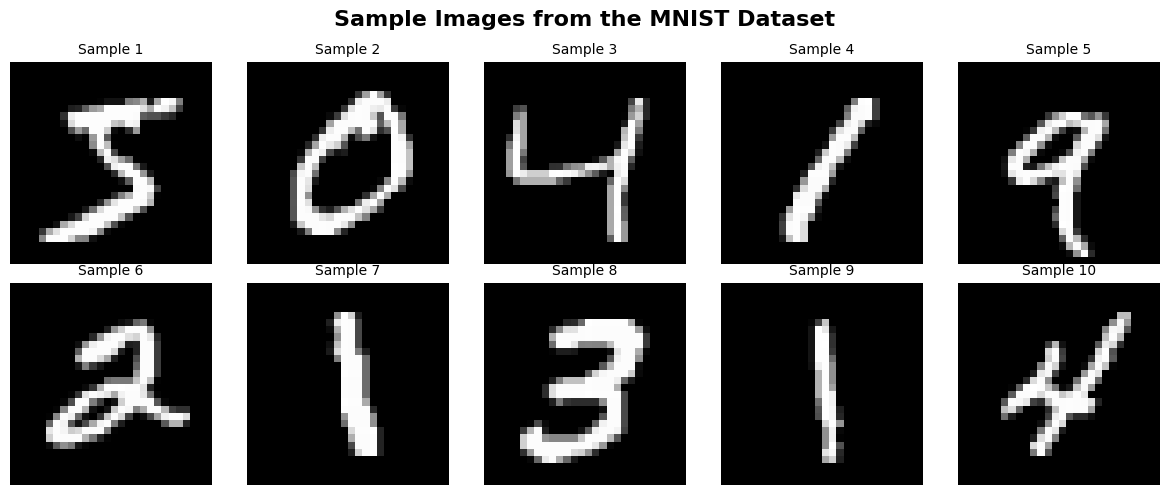

In [40]:
# ==========================================================
# 🖼️ Display Sample Images
# ==========================================================

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Sample {i+1}", fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from the MNIST Dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 📌 Observations

From the dataset exploration, we observe that:

- The dataset contains **60,000 training** and **10,000 testing** grayscale images.
- Each image has a resolution of **28 × 28 pixels**.
- Pixel intensity values range from **0 to 255**.
- The dataset is balanced and widely used as a benchmark for image processing and deep learning tasks.
- Since Autoencoders perform image reconstruction, only the image data is required, while class labels are intentionally ignored.

With the dataset successfully loaded and explored, the next step is to preprocess the images by normalizing the pixel values and reshaping them to match the input requirements of the Convolutional Neural Network.


# 🔄 Step 6: Data Preprocessing

Before training the Autoencoder, the images are preprocessed to improve learning efficiency.

The preprocessing steps include:

- Normalizing pixel values from **0–255** to **0–1**
- Adding a channel dimension to make the data compatible with convolutional layers

These steps ensure numerical stability and prepare the images for the CNN architecture.

In [41]:
# ==========================================================
# 🔄 Normalize and Reshape Images
# ==========================================================

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

print("\nPixel Range")
print("Minimum :", x_train.min())
print("Maximum :", x_train.max())

Training Shape : (60000, 28, 28, 1)
Testing Shape  : (10000, 28, 28, 1)

Pixel Range
Minimum : 0.0
Maximum : 1.0


# 🌧️ Step 7: Add Gaussian Noise

To train the denoising Autoencoder, artificial Gaussian noise is added to the original images.

The model learns to map:

**Noisy Image → Clean Image**

This enables it to reconstruct high-quality images even when the input is corrupted.

In [42]:
# ==========================================================
# 🌧️ Generate Noisy Images
# ==========================================================

noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep values within [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

print("Noisy images created successfully!")

Noisy images created successfully!


# 🖼️ Step 8: Original vs Noisy Images

Before training the model, let's compare the original handwritten digits with their noisy counterparts.

This comparison illustrates the corruption introduced by Gaussian noise and highlights the challenge the Autoencoder must solve.

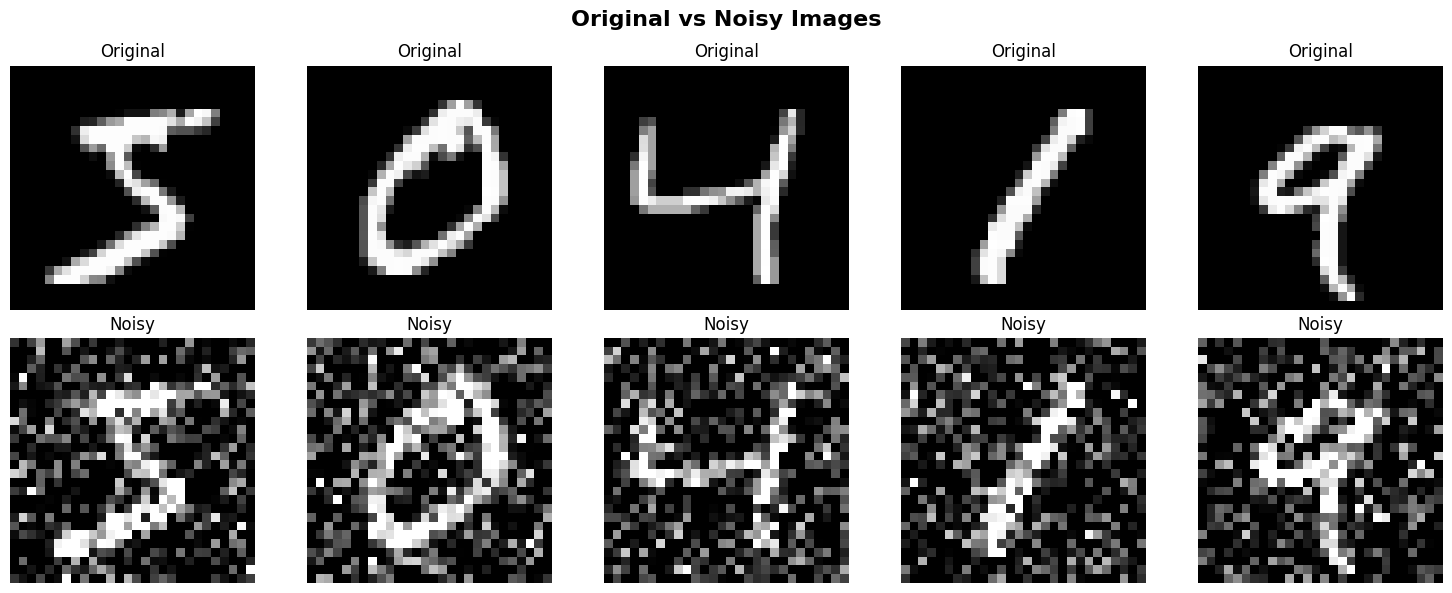

In [43]:
# ==========================================================
# 🖼️ Compare Original and Noisy Images
# ==========================================================

plt.figure(figsize=(15,6))

for i in range(5):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.suptitle("Original vs Noisy Images", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 🏗️ Step 9: Build the Convolutional Autoencoder

The Autoencoder consists of two main components:

### Encoder
- Extracts meaningful features
- Compresses the image into a latent representation

### Decoder
- Reconstructs the clean image
- Learns to remove noise while preserving important digit structures

The network uses convolutional layers for feature extraction and upsampling layers for image reconstruction.

In [44]:
# ============================================
# 🧠 Convolutional Autoencoder
# ============================================

input_img = layers.Input(shape=(28, 28, 1))

# ---------------- Encoder ----------------

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

# ---------------- Decoder ----------------

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = layers.BatchNormalization()(x)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,265 (294.00 KB)

 Trainable params: 74,881 (292.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [45]:
# ==========================================================
# ⚙️ Compile Model
# ==========================================================

autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['mse']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [46]:
# ==========================================================
# 📌 Training Callbacks
# ==========================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

In [47]:
# ==========================================================
# 🚀 Train Autoencoder
# ==========================================================

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.1496 - mse: 0.0236 - val_loss: 0.1444 - val_mse: 0.0250 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0902 - mse: 0.0090 - val_loss: 0.0897 - val_mse: 0.0091 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0881 - mse: 0.0084 - val_loss: 0.0885 - val_mse: 0.0087 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0870 - mse: 0.0081 - val_loss: 0.0871 - val_mse: 0.0083 - learning_rate: 0.0010
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0863 - mse: 0.0079 - val_loss: 0.0858 - val_mse: 0.0079 - learning_rate: 0.0010
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0858 - mse: 0.0077 - val_loss: 0.0857 - val_mse: 0.0078 - learning_rate: 0.0010
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0853 - mse: 0.0076 - val_loss: 0.0853 - val_mse: 0.0077 - learning_rate: 0.0010
Epoc

# 📈 Step 10: Model Training Performance

The training and validation loss curves help us evaluate the learning behavior of the Autoencoder.

A decreasing loss indicates that the model is successfully learning to reconstruct clean images from noisy inputs.

A small gap between training and validation loss suggests good generalization with minimal overfitting.

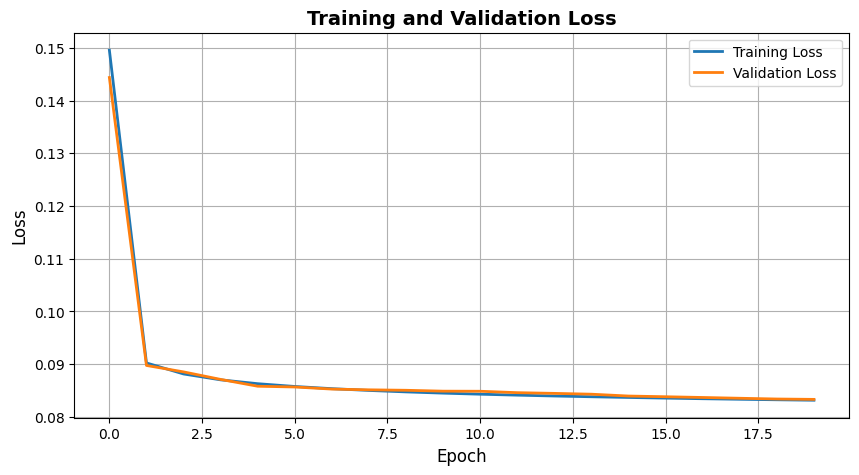

In [48]:
# ==========================================================
# 📈 Plot Training History
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Training and Validation Loss", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(True)

plt.show()

# 📊 Model Evaluation

Now we evaluate the trained model on the noisy test images.

The model predicts reconstructed (denoised) images, which are then compared with the original clean images.

In [49]:
test_loss, test_mse = autoencoder.evaluate(
    x_test_noisy,
    x_test,
    verbose=0
)

print("="*45)
print("Model Evaluation Results")
print("="*45)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test MSE  : {test_mse:.6f}")

Model Evaluation Results
Test Loss : 0.0833
Test MSE  : 0.007089


# 🖼️ Step 11: Image Reconstruction

After training, the Autoencoder is used to reconstruct clean images from noisy inputs.

The reconstructed images are then compared with:

- Original Images
- Noisy Images
- Reconstructed Images

This visual comparison demonstrates the denoising capability of the model.

In [50]:
decoded_images = autoencoder.predict(x_test_noisy)

print("Prediction Completed Successfully!")
print("Shape of Reconstructed Images:", decoded_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Prediction Completed Successfully!
Shape of Reconstructed Images: (10000, 28, 28, 1)


# 🔍 Visual Comparison

The following visualization compares:

1. Original Image
2. Noisy Image
3. Reconstructed Image

This helps us understand how effectively the autoencoder removes Gaussian noise.

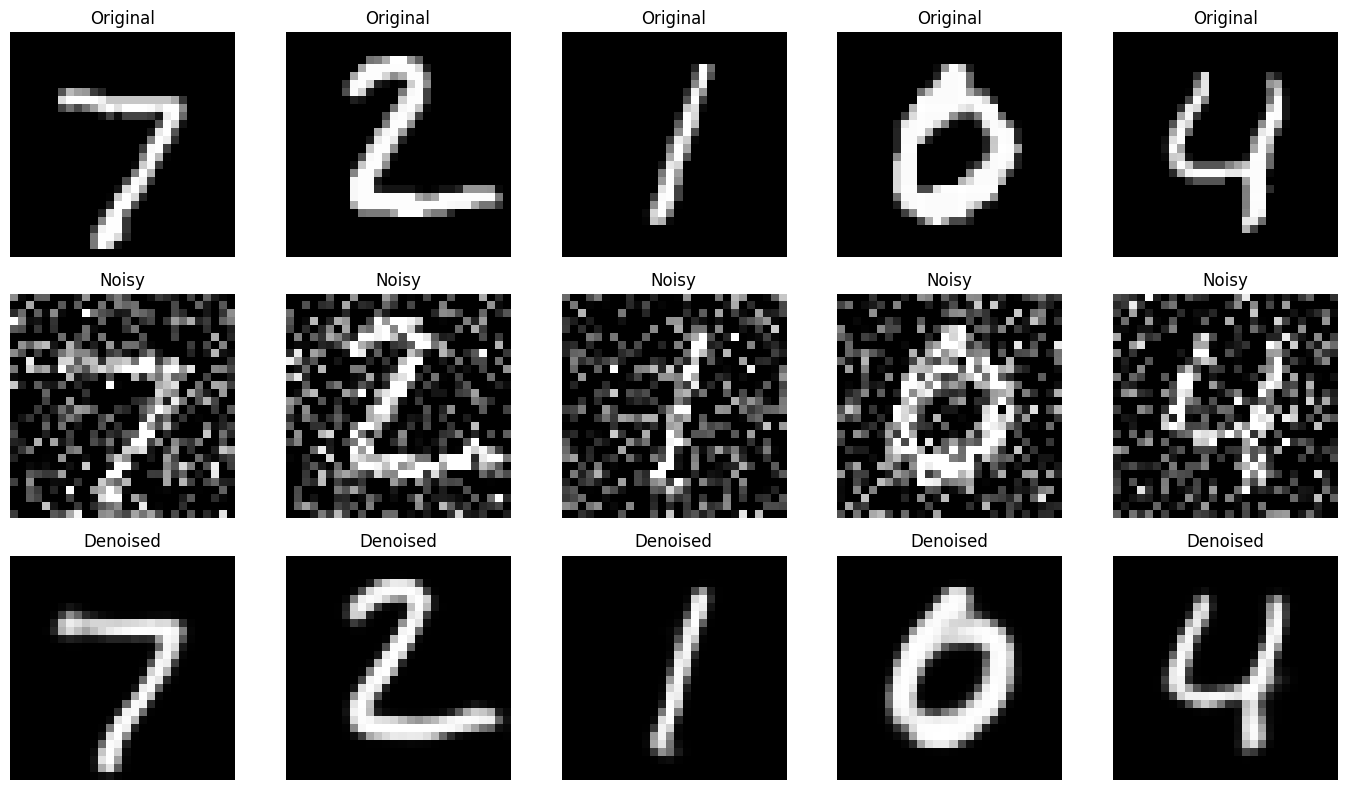

In [51]:
n = 5

plt.figure(figsize=(14,8))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(decoded_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

# 🎲 Random Image Reconstruction

Instead of displaying the first few test images, we randomly select samples from the test dataset.

This demonstrates that the trained autoencoder performs well on unseen handwritten digits and is not limited to a fixed set of examples.

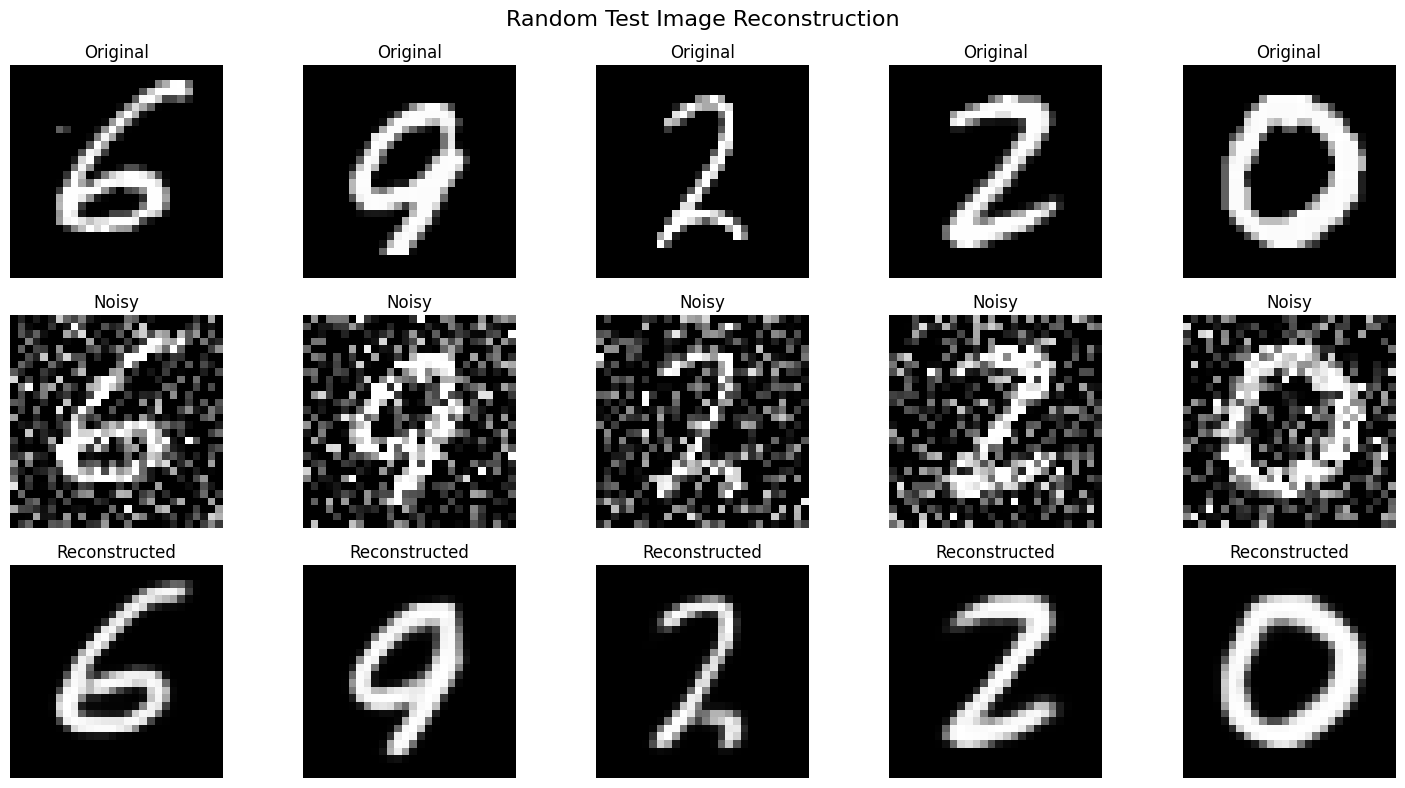

In [52]:
# Select random test images
num_images = 5
random_indices = np.random.choice(len(x_test), num_images, replace=False)

plt.figure(figsize=(15, 8))

for i, idx in enumerate(random_indices):

    # Original Image
    plt.subplot(3, num_images, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(3, num_images, i + num_images + 1)
    plt.imshow(x_test_noisy[idx].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed Image
    plt.subplot(3, num_images, i + 2 * num_images + 1)
    plt.imshow(decoded_images[idx].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.suptitle("Random Test Image Reconstruction", fontsize=16)
plt.tight_layout()
plt.show()

# 📉 Reconstruction Error

The Mean Squared Error (MSE) measures the average squared difference between the original clean images and the reconstructed images.

A lower MSE indicates better image reconstruction quality.

In [53]:
# Calculate Mean Squared Error
mse = np.mean((decoded_images - x_test) ** 2)

print("=" * 50)
print("Reconstruction Evaluation")
print("=" * 50)
print(f"Mean Squared Error (MSE): {mse:.6f}")

Reconstruction Evaluation
Mean Squared Error (MSE): 0.007089


# 📊 Peak Signal-to-Noise Ratio (PSNR)

Peak Signal-to-Noise Ratio (PSNR) is a widely used metric to evaluate image reconstruction quality.

Higher PSNR values indicate that the reconstructed image is closer to the original image.

In [54]:
# Calculate PSNR
psnr = 10 * np.log10(1.0 / mse)

print("=" * 50)
print(f"PSNR: {psnr:.2f} dB")
print("=" * 50)

PSNR: 21.49 dB


# 🔥 Pixel-wise Error Heatmap

The heatmap below highlights the absolute difference between the original image and its reconstructed version.

Brighter pixels indicate regions where the reconstruction error is higher.

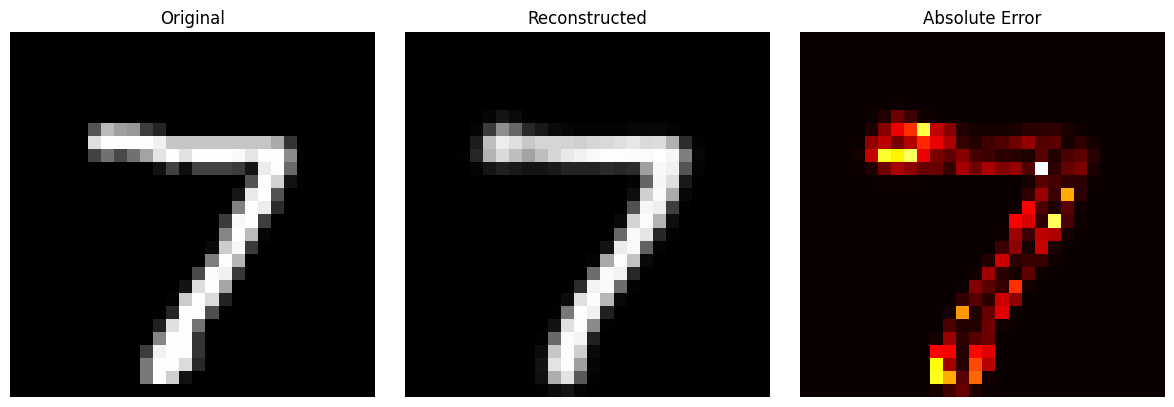

In [55]:
sample = 0

error = np.abs(x_test[sample] - decoded_images[sample])

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(x_test[sample].reshape(28, 28), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(decoded_images[sample].reshape(28, 28), cmap="gray")
plt.title("Reconstructed")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(error.reshape(28, 28), cmap="hot")
plt.title("Absolute Error")
plt.axis("off")

plt.tight_layout()
plt.show()

# 📋 Project Summary

The table below summarizes the important details of the implemented Autoencoder model.

In [56]:
summary = {
    "Dataset": "MNIST Handwritten Digits",
    "Training Images": len(x_train),
    "Testing Images": len(x_test),
    "Image Size": "28 × 28",
    "Noise Type": "Gaussian Noise",
    "Noise Factor": 0.4,
    "Model": "Convolutional Autoencoder",
    "Optimizer": "Adam",
    "Loss Function": "Binary Crossentropy",
    "Evaluation Metric": "Mean Squared Error (MSE)"
}

print("=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

for key, value in summary.items():
    print(f"{key:<20}: {value}")

PROJECT SUMMARY
Dataset             : MNIST Handwritten Digits
Training Images     : 60000
Testing Images      : 10000
Image Size          : 28 × 28
Noise Type          : Gaussian Noise
Noise Factor        : 0.4
Model               : Convolutional Autoencoder
Optimizer           : Adam
Loss Function       : Binary Crossentropy
Evaluation Metric   : Mean Squared Error (MSE)


# 🔍 Key Observations

- The Convolutional Autoencoder successfully learned meaningful latent representations of handwritten digits.
- Training and validation losses decreased consistently, indicating effective learning.
- The reconstructed images closely resemble the original clean images despite the added Gaussian noise.
- The low Mean Squared Error (MSE) and high PSNR indicate good reconstruction quality.
- Convolutional layers effectively preserve important spatial features, making CNN Autoencoders well-suited for image denoising tasks.

# 🌍 Real-World Applications

Autoencoders have numerous applications in computer vision and deep learning, including:

- 🏥 Medical image denoising (MRI, CT Scan, X-ray enhancement)
- 🛰️ Satellite and remote sensing image restoration
- 📄 Document and OCR preprocessing
- 📷 Digital camera noise reduction
- 🚗 Autonomous vehicle vision systems
- 🎭 Image compression and feature extraction
- 🔍 Anomaly detection in industrial inspection
- 🤖 Representation learning for deep neural networks

# 🚀 Future Scope

The performance of this project can be further improved by exploring advanced deep learning techniques such as:

- Variational Autoencoders (VAE)
- Denoising Autoencoders with different noise distributions
- Generative Adversarial Networks (GANs)
- Diffusion Models
- Residual Autoencoders
- Attention-based Autoencoders
- High-resolution image restoration
- Color image denoising

# ✅ Conclusion

In this project, a **Convolutional Autoencoder** was successfully developed to remove Gaussian noise from handwritten digit images using the **MNIST dataset**.

The model learned a compressed latent representation of noisy images and reconstructed clean images with high visual quality. The gradual reduction in both training and validation losses demonstrates effective learning without significant overfitting.

Evaluation metrics such as **Mean Squared Error (MSE)** and **Peak Signal-to-Noise Ratio (PSNR)** confirmed the model's strong reconstruction capability. Visual comparisons between original, noisy, and reconstructed images further demonstrated the effectiveness of the proposed architecture.

Overall, this project highlights the practical application of Autoencoders in image denoising and provides a strong foundation for more advanced generative deep learning models such as Variational Autoencoders (VAEs) and Generative Adversarial Networks (GANs).

# 📚 References

1. TensorFlow Documentation – https://www.tensorflow.org/
2. Keras Documentation – https://keras.io/
3. MNIST Database – http://yann.lecun.com/exdb/mnist/
4. Celebal Technologies – Week 6 Assignment Material
5. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.

## 🎉 Thank You

Thank you for reviewing this project.

This notebook demonstrates the implementation of a Convolutional Autoencoder for image denoising using the MNIST dataset as part of the Celebal Excellence Internship (CEI) Program 2026 - Week 6 Assignment.